In [2]:
import pandas as pd 

In [3]:
df=pd.read_csv('future_jobs_dataset.csv')

In [6]:
df.head()

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"Linear Algebra, Quantum Algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"Climate Data Analysis, Energy Modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"Linear Algebra, Qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"Climate Data Analysis, Energy Modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"Rust, Solidity",Yes,Small,2025-03-30


In [7]:
df.shape

(10000, 9)

In [ ]:
# problem 1-> salay(regression)
# problem 2-> category(classificatin)
# problem 3-> demand skills

In [8]:
df.isnull().sum()

job_id             0
job_title          0
industry           0
location           0
salary_usd         0
skills_required    0
remote_option      0
company_size       0
posting_date       0
dtype: int64

In [10]:
df['job_title'].value_counts()

job_title
Quantum Software Developer    1278
Smart Contract Engineer       1255
Renewable Energy Engineer     1253
Blockchain Developer          1244
Quantum Researcher            1241
Sustainability Analyst        1237
AI Engineer                    863
Data Scientist                 817
ML Researcher                  812
Name: count, dtype: int64

In [13]:
df.isnull().sum()

job_id             0
job_title          0
industry           0
location           0
salary_usd         0
skills_required    0
remote_option      0
company_size       0
posting_date       0
dtype: int64

In [4]:
df['posting_date']

0       2025-07-22
1       2025-09-26
2       2025-12-31
3       2025-05-29
4       2025-03-30
           ...    
9995    2025-04-13
9996    2025-11-03
9997    2025-02-23
9998    2025-03-08
9999    2025-08-12
Name: posting_date, Length: 10000, dtype: object

In [20]:
df.describe()

,job_id,salary_usd
count,10000.00000,10000.000000
mean,5000.50000,150131.524800
std,2886.89568,57534.947278
min,1.00000,50013.000000
25%,2500.75000,100568.000000
50%,5000.50000,150398.500000
75%,7500.25000,199225.250000
max,10000.00000,249990.000000


In [21]:
df['skills_required'].value_counts()

skills_required
Energy Modeling, Climate Data Analysis    1255
Climate Data Analysis, Energy Modeling    1235
Ethereum, Solidity                         454
Python, TensorFlow                         439
Quantum Algorithms, Qiskit                 435
Linear Algebra, Qiskit                     424
TensorFlow, PyTorch                        424
Quantum Algorithms, Linear Algebra         424
Qiskit, Quantum Algorithms                 418
Ethereum, Rust                             417
TensorFlow, Python                         416
Linear Algebra, Quantum Algorithms         413
Rust, Ethereum                             413
PyTorch, TensorFlow                        411
Solidity, Rust                             409
Rust, Solidity                             407
Qiskit, Linear Algebra                     405
Python, PyTorch                            404
Solidity, Ethereum                         399
PyTorch, Python                            398
Name: count, dtype: int64

In [24]:
df['location'].value_counts()

location
New York     1689
Singapore    1682
Tokyo        1673
Dubai        1660
London       1656
Berlin       1640
Name: count, dtype: int64

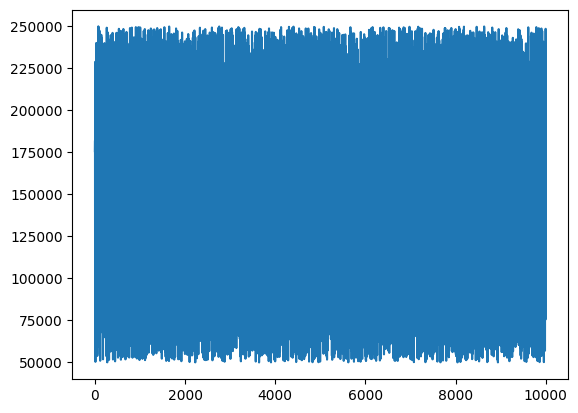

In [ ]:
plt.plot(df['salary_usd'])

In [6]:
import matplotlib.pyplot as plt

d:\DataScience and AI programming\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


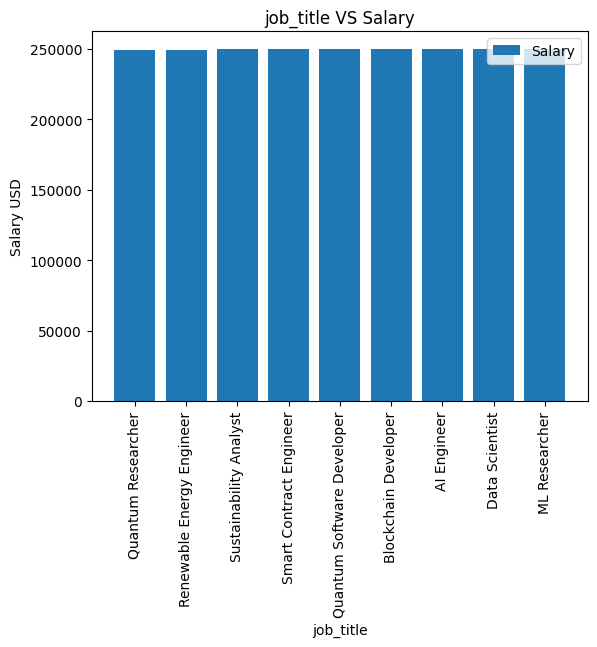

In [12]:
plt.bar(df['job_title'],df['salary_usd'],label='Salary')
plt.xticks(rotation=90)
plt.title('job_title VS Salary')
plt.xlabel('job_title')
plt.ylabel('Salary USD')
plt.legend()
plt.show()

C:\Users\Waheed khan\AppData\Local\Temp\ipykernel_4728\991012062.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


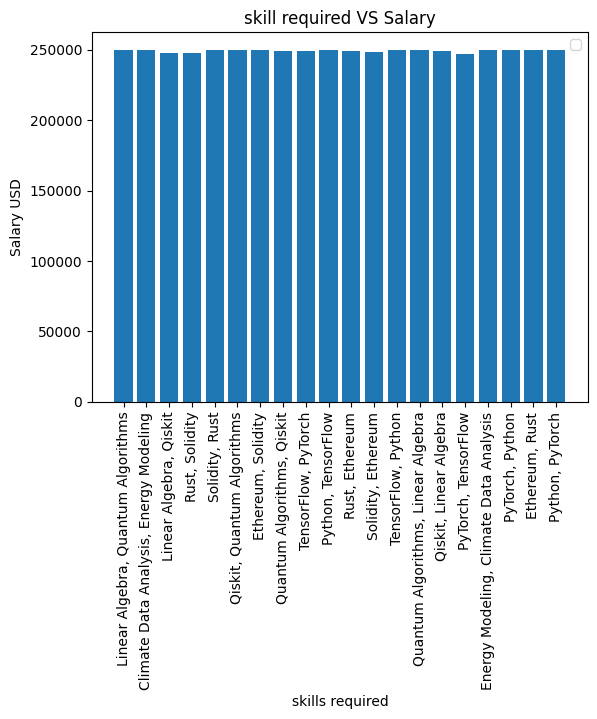

In [13]:
plt.bar(df['skills_required'],df['salary_usd'])
plt.xticks(rotation=90)
plt.title('skill required VS Salary')
plt.xlabel('skills required')
plt.ylabel('Salary USD')
plt.legend()
plt.show()

In [16]:
cor_relationship=df.corr(numeric_only=True)
cor_relationship

,job_id,salary_usd
job_id,1.000000,-0.007151
salary_usd,-0.007151,1.000000


<Axes: >

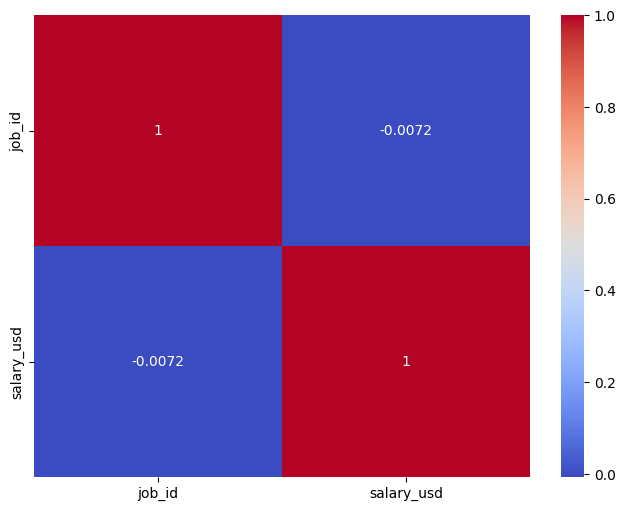

In [17]:
import seaborn as sns 
plt.figure(figsize=(8,6))
sns.heatmap(cor_relationship,annot=True,cmap='coolwarm')

Feature Engineering

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           10000 non-null  int64 
 1   job_title        10000 non-null  object
 2   industry         10000 non-null  object
 3   location         10000 non-null  object
 4   salary_usd       10000 non-null  int64 
 5   skills_required  10000 non-null  object
 6   remote_option    10000 non-null  object
 7   company_size     10000 non-null  object
 8   posting_date     10000 non-null  object
dtypes: int64(2), object(7)
memory usage: 703.3+ KB


In [8]:
# to convert in the data type
df['posting_date']=pd.to_datetime(df['posting_date'])

In [9]:
df['quarter']=df['posting_date'].dt.quarter
df['months']=df['posting_date'].dt.month
df['year']=df['posting_date'].dt.year

In [7]:
df[['posting_date','days','quarter','months','year']]

,posting_date,days,quarter,months,year
0,2025-07-22,22,3,7,2025
1,2025-09-26,26,3,9,2025
2,2025-12-31,31,4,12,2025
3,2025-05-29,29,2,5,2025
4,2025-03-30,30,1,3,2025
...,...,...,...,...,...
9995,2025-04-13,13,2,4,2025
9996,2025-11-03,3,4,11,2025
9997,2025-02-23,23,1,2,2025
9998,2025-03-08,8,1,3,2025


In [8]:
df['year'].value_counts()

year
2025    10000
Name: count, dtype: int64

In [9]:
df['skills_required'].value_counts()

skills_required
Energy Modeling, Climate Data Analysis    1255
Climate Data Analysis, Energy Modeling    1235
Ethereum, Solidity                         454
Python, TensorFlow                         439
Quantum Algorithms, Qiskit                 435
Linear Algebra, Qiskit                     424
TensorFlow, PyTorch                        424
Quantum Algorithms, Linear Algebra         424
Qiskit, Quantum Algorithms                 418
Ethereum, Rust                             417
TensorFlow, Python                         416
Linear Algebra, Quantum Algorithms         413
Rust, Ethereum                             413
PyTorch, TensorFlow                        411
Solidity, Rust                             409
Rust, Solidity                             407
Qiskit, Linear Algebra                     405
Python, PyTorch                            404
Solidity, Ethereum                         399
PyTorch, Python                            398
Name: count, dtype: int64

In [13]:
df['count_skills']=0

In [14]:
df['count_skills']

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: count_skills, Length: 10000, dtype: int64

In [5]:
df['count_skills']=df['skills_required'].str.split(',').apply(len)

In [11]:
df.head(3)

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date,count_skills,quarter,months,year
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"Linear Algebra, Quantum Algorithms",No,Large,2025-07-22,2,3,7,2025
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"Climate Data Analysis, Energy Modeling",Yes,Large,2025-09-26,2,3,9,2025
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"Linear Algebra, Qiskit",No,Medium,2025-12-31,2,4,12,2025


In [12]:
df['count_skills'].value_counts()

count_skills
2    10000
Name: count, dtype: int64

In [15]:
df['skills_required'].value_counts()

skills_required
Energy Modeling, Climate Data Analysis    1255
Climate Data Analysis, Energy Modeling    1235
Ethereum, Solidity                         454
Python, TensorFlow                         439
Quantum Algorithms, Qiskit                 435
Linear Algebra, Qiskit                     424
TensorFlow, PyTorch                        424
Quantum Algorithms, Linear Algebra         424
Qiskit, Quantum Algorithms                 418
Ethereum, Rust                             417
TensorFlow, Python                         416
Linear Algebra, Quantum Algorithms         413
Rust, Ethereum                             413
PyTorch, TensorFlow                        411
Solidity, Rust                             409
Rust, Solidity                             407
Qiskit, Linear Algebra                     405
Python, PyTorch                            404
Solidity, Ethereum                         399
PyTorch, Python                            398
Name: count, dtype: int64

In [14]:
df['job_title'].value_counts()

job_title
Quantum Software Developer    1278
Smart Contract Engineer       1255
Renewable Energy Engineer     1253
Blockchain Developer          1244
Quantum Researcher            1241
Sustainability Analyst        1237
AI Engineer                    863
Data Scientist                 817
ML Researcher                  812
Name: count, dtype: int64

In [6]:
df.columns

Index(['job_id', 'job_title', 'industry', 'location', 'salary_usd',
       'skills_required', 'remote_option', 'company_size', 'posting_date',
       'count_skills'],
      dtype='object')


-->for category prediction 
important features 
    job title
    skills_required
    target ->industry
less important
    count skills 
\n

--> for salary prediction 
important features 
--job title,
--industry,
--remote option
---company size
--skill required
less 
--post date
--count skills

    

Model training for category selection

In [1]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.tree  import DecisionTreeClassifier
from xgboost import XGBClassifier

In [7]:
df.columns

Index(['job_id', 'job_title', 'industry', 'location', 'salary_usd',
       'skills_required', 'remote_option', 'company_size', 'posting_date',
       'count_skills'],
      dtype='object')

In [10]:
x=df[['job_title','skills_required','count_skills']]

y=df['industry']


In [11]:
df.head()

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date,count_skills
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"Linear Algebra, Quantum Algorithms",No,Large,2025-07-22,2
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"Climate Data Analysis, Energy Modeling",Yes,Large,2025-09-26,2
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"Linear Algebra, Qiskit",No,Medium,2025-12-31,2
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"Climate Data Analysis, Energy Modeling",No,Large,2025-05-29,2
4,5,Smart Contract Engineer,Blockchain,London,92575,"Rust, Solidity",Yes,Small,2025-03-30,2
